In [2]:
import torch
from torch import nn
import sklearn

In [3]:
from sklearn.datasets import make_circles
n_samples = 1000
X, y = make_circles(n_samples,noise=0.03,random_state=42)

In [5]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
[1 1 1 1 0]


In [4]:
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],"X2": X[:, 1],"label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [5]:
print(circles.label.value_counts())
circles.X1.value_counts()

label
1    500
0    500
Name: count, dtype: int64


,count
X1,
0.281057,1
0.754246,1
-0.756159,1
-0.815392,1
-0.393731,1
...,...
-0.117736,1
0.569467,1
-0.642490,1


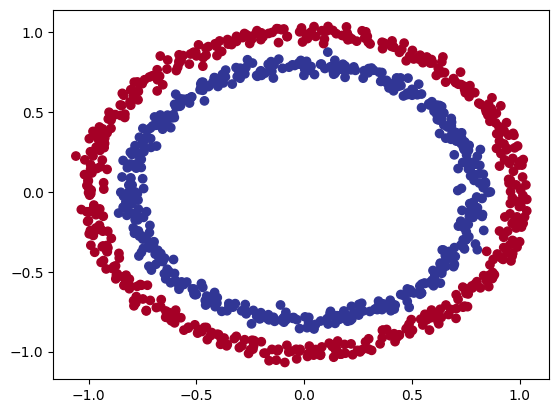

In [14]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],y=X[:, 1],c=y,cmap=plt.cm.RdYlBu);

In [7]:
X.shape,y.shape

(torch.Size([1000, 2]), torch.Size([1000]))

In [6]:
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)
X[:5],y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
len(X_train),len(X_test),len(y_train),len(y_test)

(800, 200, 800, 200)

the above info tells us that both X and y will be trained on 800 values which means both of them would get the same chance to train themselves and the testing would take place on the same (quantitive wise ) 200 values for both X and y.

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)
    def forward(self, x):
        return self.layer_2(self.layer_1(x))
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

the first layer takes two values of X as inputs and then returns five values (weights) to the layer2 which takes these five weights as input and give one output as a result.

In [10]:
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [11]:
def accuracy(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc



In [16]:
torch.manual_seed(42)
epochs = 1000
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
for epoch in range(epochs):
    model_0.train()
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits, y_train)
    acc = accuracy(y_true=y_train, y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Calculate loss/accuracy
        test_loss = loss_fn(test_logits, y_test) # Use the instantiated loss function
        test_acc = accuracy(y_true=y_test, y_pred=test_pred) # Use the defined accuracy function

    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69300, Accuracy: 50.75% | Test loss: 0.69458, Test acc: 46.50%
Epoch: 10 | Loss: 0.69300, Accuracy: 50.75% | Test loss: 0.69459, Test acc: 46.00%
Epoch: 20 | Loss: 0.69300, Accuracy: 50.38% | Test loss: 0.69459, Test acc: 45.50%
Epoch: 30 | Loss: 0.69300, Accuracy: 50.62% | Test loss: 0.69460, Test acc: 46.00%
Epoch: 40 | Loss: 0.69299, Accuracy: 50.50% | Test loss: 0.69460, Test acc: 46.00%
Epoch: 50 | Loss: 0.69299, Accuracy: 50.62% | Test loss: 0.69460, Test acc: 47.50%
Epoch: 60 | Loss: 0.69299, Accuracy: 50.88% | Test loss: 0.69461, Test acc: 47.50%
Epoch: 70 | Loss: 0.69299, Accuracy: 50.88% | Test loss: 0.69461, Test acc: 48.00%
Epoch: 80 | Loss: 0.69299, Accuracy: 51.12% | Test loss: 0.69462, Test acc: 48.00%
Epoch: 90 | Loss: 0.69299, Accuracy: 51.00% | Test loss: 0.69462, Test acc: 48.00%
Epoch: 100 | Loss: 0.69299, Accuracy: 51.00% | Test loss: 0.69462, Test acc: 47.00%
Epoch: 110 | Loss: 0.69299, Accuracy: 51.00% | Test loss: 0.69462, Test acc: 47.00%
Epo

In [22]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10) # extra layer
        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x): # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [24]:
torch.manual_seed(42)
epochs = 1000
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
for epoch in range(epochs):
    model_1.train()
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits, y_train)
    acc = accuracy(y_true=y_train, y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Calculate loss/accuracy
        test_loss = loss_fn(test_logits, y_test) # Use the instantiated loss function
        test_acc = accuracy(y_true=y_test, y_pred=test_pred) # Use the defined accuracy function

    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396, Accuracy: 50.88% | Test loss: 0.69261, Test acc: 51.00%
Epoch: 10 | Loss: 0.69369, Accuracy: 50.25% | Test loss: 0.69270, Test acc: 50.00%
Epoch: 20 | Loss: 0.69351, Accuracy: 50.12% | Test loss: 0.69283, Test acc: 49.50%
Epoch: 30 | Loss: 0.69339, Accuracy: 50.50% | Test loss: 0.69297, Test acc: 48.00%
Epoch: 40 | Loss: 0.69329, Accuracy: 50.38% | Test loss: 0.69310, Test acc: 49.00%
Epoch: 50 | Loss: 0.69322, Accuracy: 49.88% | Test loss: 0.69324, Test acc: 50.00%
Epoch: 60 | Loss: 0.69317, Accuracy: 49.38% | Test loss: 0.69336, Test acc: 51.50%
Epoch: 70 | Loss: 0.69312, Accuracy: 49.38% | Test loss: 0.69348, Test acc: 50.50%
Epoch: 80 | Loss: 0.69309, Accuracy: 50.12% | Test loss: 0.69359, Test acc: 50.00%
Epoch: 90 | Loss: 0.69307, Accuracy: 50.50% | Test loss: 0.69370, Test acc: 48.50%
Epoch: 100 | Loss: 0.69305, Accuracy: 50.38% | Test loss: 0.69379, Test acc: 48.00%
Epoch: 110 | Loss: 0.69303, Accuracy: 50.88% | Test loss: 0.69388, Test acc: 46.50%
Epo

the model is just simply doing is making a straight line among the label of 0 and 1 which is no better than random guessing and the model has yet to understand or recognize the patterns lying within the model

In [25]:
# Build model with non-linear activation function
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
print(model_3)

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [26]:
# Setup loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)

In [28]:

torch.manual_seed(42)
epochs = 1000
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits, y_train)
    acc = accuracy(y_true=y_train,
                      y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### Testing
    model_3.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_3(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits)) # logits -> prediction probabilities -> prediction labels
      # 2. Calculate loss and accuracy
      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy(y_true=y_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.56818, Accuracy: 87.75% | Test Loss: 0.57378, Test Accuracy: 86.50%
Epoch: 100 | Loss: 0.48153, Accuracy: 93.50% | Test Loss: 0.49935, Test Accuracy: 90.50%
Epoch: 200 | Loss: 0.37056, Accuracy: 97.75% | Test Loss: 0.40595, Test Accuracy: 92.00%
Epoch: 300 | Loss: 0.25458, Accuracy: 99.00% | Test Loss: 0.30333, Test Accuracy: 96.50%
Epoch: 400 | Loss: 0.17180, Accuracy: 99.50% | Test Loss: 0.22108, Test Accuracy: 97.50%
Epoch: 500 | Loss: 0.12188, Accuracy: 99.62% | Test Loss: 0.16512, Test Accuracy: 99.00%
Epoch: 600 | Loss: 0.09123, Accuracy: 99.88% | Test Loss: 0.12741, Test Accuracy: 99.50%
Epoch: 700 | Loss: 0.07100, Accuracy: 99.88% | Test Loss: 0.10319, Test Accuracy: 99.50%
Epoch: 800 | Loss: 0.05773, Accuracy: 99.88% | Test Loss: 0.08672, Test Accuracy: 99.50%
Epoch: 900 | Loss: 0.04853, Accuracy: 99.88% | Test Loss: 0.07474, Test Accuracy: 99.50%


by using the relu after the simple hidden layers we have seen the drastic increaase within the accuracy of the modelv3 which can be seen aas the commanding factor to what the modelv1 and modelv2 weren't doing as they both were dealing with the dataset as they were dealing with a simple linear dataset due to which it was at max randomly guessing the solution and not learning much from it but with the help of relu the model learned the complex non linear structure underlying within the data and produced great accuracy os 99.50.

tensor([[ -8.5714,   8.6663,   9.8848,  -6.6618,  -5.2504],
        [ -5.6494,  -8.0774,   8.9235,   3.7762,   6.2347],
        [  4.0851,  -6.3081,  -9.8725,   3.9239,  -2.5361],
        [ -5.0133,   9.8293,   3.6459,   2.8291,  -8.0245],
        [ -6.6459,   0.2966, -12.2366,   7.6601,  -8.1519]]) tensor([2, 1, 7, 0, 8])


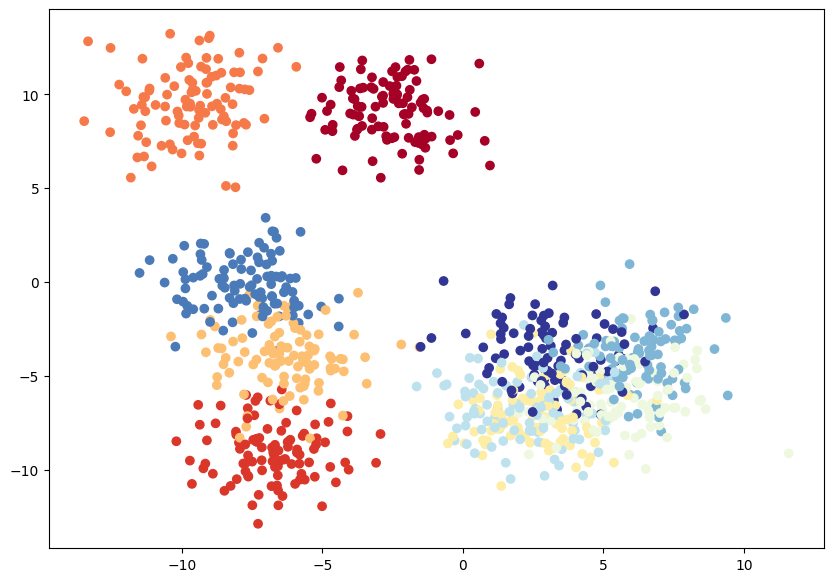

In [10]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
NUM_CLASSES = 10
NUM_FEATURES = 5
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(n_samples=1000,
    n_features=NUM_FEATURES, # X features
    centers=NUM_CLASSES, # y labels
    cluster_std=1.5,
    random_state=RANDOM_SEED
)

# 2. Turning data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
print(X_blob[:5], y_blob[:5])

# 3. Splitting into train and test sets
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
    y_blob,
    test_size=0.2,
    random_state=RANDOM_SEED
)

# 4. Plot data
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [6]:
from torch import nn

# Build model
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_features), # how many classes are there?
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

model_4 = BlobModel(input_features=NUM_FEATURES,
                    output_features=NUM_CLASSES,
                    hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=5, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=10, bias=True)
  )
)

In [11]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_4.parameters(), lr=0.1)

In [15]:

model_4(X_blob_train.to(device))[:5]
print(model_4(X_blob_train.to(device))[0].shape, NUM_CLASSES )
y_logits = model_4(X_blob_test.to(device))
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

torch.Size([10]) 10
tensor([[-0.7514,  0.2512,  0.5805,  0.6466, -0.3093, -0.1952, -0.6746,  0.7903,
         -0.6912, -1.1358],
        [ 0.3390,  0.1739,  0.5945, -0.7392,  0.6217,  0.1165,  0.4420, -0.7804,
         -0.5196, -0.7371],
        [ 0.5372,  0.7248,  0.2525,  1.8378, -1.3184,  0.0875,  0.4076, -0.3881,
          0.4996,  0.9767],
        [ 0.4426,  1.1392,  0.5806, -0.2357,  0.0025,  0.1680,  0.9021, -0.1992,
         -0.5879,  0.1893],
        [-0.7601,  0.4159, -0.0447, -1.3280, -0.3511,  1.2454,  1.0190,  0.5854,
         -1.1277,  0.8659]], grad_fn=<SliceBackward0>)
tensor([[0.0447, 0.1219, 0.1695, 0.1810, 0.0696, 0.0780, 0.0483, 0.2090, 0.0475,
         0.0305],
        [0.1281, 0.1086, 0.1654, 0.0436, 0.1700, 0.1026, 0.1420, 0.0418, 0.0543,
         0.0437],
        [0.0892, 0.1076, 0.0671, 0.3274, 0.0139, 0.0569, 0.0783, 0.0353, 0.0859,
         0.1384],
        [0.1074, 0.2156, 0.1233, 0.0545, 0.0692, 0.0816, 0.1701, 0.0565, 0.0383,
         0.0834],
        [0.0

In [17]:
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([0.0447, 0.1219, 0.1695, 0.1810, 0.0696, 0.0780, 0.0483, 0.2090, 0.0475,
        0.0305], grad_fn=<SelectBackward0>)
tensor(7)


In [19]:
def accuracy(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

torch.manual_seed(42)
epochs = 100
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    model_4.train()
    y_logits = model_4(X_blob_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    # print(y_logits)
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy(y_true=y_blob_train,
                      y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### Testing
    model_4.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_logits = model_4(X_blob_test)
      test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
      # 2. Calculate test loss and accuracy
      test_loss = loss_fn(test_logits, y_blob_test)
      test_acc = accuracy(y_true=y_blob_test,
                             y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 2.64637, Acc: 3.12% | Test Loss: 2.24403, Test Acc: 6.00%
Epoch: 10 | Loss: 0.80299, Acc: 85.50% | Test Loss: 0.68721, Test Acc: 89.50%
Epoch: 20 | Loss: 0.34823, Acc: 90.00% | Test Loss: 0.29505, Test Acc: 91.50%
Epoch: 30 | Loss: 0.23913, Acc: 90.88% | Test Loss: 0.20175, Test Acc: 92.00%
Epoch: 40 | Loss: 0.19898, Acc: 92.12% | Test Loss: 0.16630, Test Acc: 92.50%
Epoch: 50 | Loss: 0.17836, Acc: 92.00% | Test Loss: 0.14818, Test Acc: 92.00%
Epoch: 60 | Loss: 0.16574, Acc: 91.50% | Test Loss: 0.13744, Test Acc: 93.50%
Epoch: 70 | Loss: 0.15716, Acc: 92.38% | Test Loss: 0.13051, Test Acc: 93.50%
Epoch: 80 | Loss: 0.15092, Acc: 92.62% | Test Loss: 0.12578, Test Acc: 93.50%
Epoch: 90 | Loss: 0.14613, Acc: 92.88% | Test Loss: 0.12237, Test Acc: 93.50%


since the accuracy is great even without using reLU we can expect that the dataset on which the model trained is a linear one and had it been the non linear dataset we would have to change the nn.linear with reLU.

In [20]:
# Make predictions
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

# View the first 10 predictions
y_logits[:10]

tensor([[ 6.8682e+00,  3.6678e+00,  1.5027e+01,  7.7152e+00, -6.6897e+00,
         -6.5825e+00, -1.0549e+01, -1.1917e+01, -3.1307e-01,  1.4546e+00],
        [-1.1638e+00, -9.2204e+00, -9.2199e+00, -3.5688e+00, -4.8128e-01,
          8.9969e+00, -3.4277e+00,  4.3847e+00, -3.0674e+00,  7.2849e+00],
        [-6.1600e+00,  1.1443e+01,  1.9083e+00,  8.4996e+00,  4.6130e+00,
         -3.7450e-01,  3.4997e+00, -1.1281e+01, -1.7455e+00, -1.4882e-01],
        [-8.0558e+00, -1.0534e+00, -3.6281e+00,  3.6534e+00,  8.1073e+00,
          2.3587e-01,  3.0405e+00,  3.3619e+00, -1.1015e+00, -6.9004e-01],
        [-4.3443e-01, -3.9043e+00, -6.1108e+00,  3.2957e+00, -3.0696e+00,
         -9.9595e-01,  2.1158e+00,  3.3262e+00,  7.4598e+00, -1.2749e+00],
        [-4.9819e+00, -8.8108e+00, -9.4086e+00, -4.4944e+00,  4.9880e+00,
          4.4585e+00,  2.1593e+00,  1.1410e+01, -1.1128e+00,  1.2347e+00],
        [ 1.0997e+00, -2.1938e+00, -6.9694e+00,  2.1215e+00, -5.4312e+00,
         -2.3009e+00,  4.7475e+0